In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
# Correr el comando para instalar librería ffmpeg
# conda install ffmpeg o pip install ffmpeg-python


Una vez se han realizado las importaciones necesarias para poder realizar el proceso, se crea una clase en la que se definen los métodos necesarios para generar la animación

In [2]:
class LorenzAnimator:
    def __init__(self, t, x, y, z, method_name="RK4"):
        """
        Parámetros:
        - t: array de tiempo
        - x, y, z: arrays de las coordenadas de la trayectoria
        - method_name: nombre del método utilizado
        """
        self.t = t
        self.x = x 
        self.y = y
        self.z = z
        self.method_name = method_name
        
        # Configuración de colores y estilo
        self.colors = plt.cm.plasma(np.linspace(0, 1, len(t)))
        self.trail_length = min(500, len(t)//4)  # Longitud de la estela
        
    def create_animation(self, filename="lorenz_attractor.mp4",fps=30, duration=10, dpi=150
        ):
        """
        Parámetros:
        - filename: nombre del archivo de salida
        - fps: frames por segundo
        - duration: duración en segundos
        - dpi: resolución
        """
        
        # Configuración de la figura
        fig = plt.figure(figsize=(12, 10))
        fig.patch.set_facecolor('black')
        
        # Subplot principal (3D)
        ax_3d = fig.add_subplot(221, projection='3d')
        ax_3d.set_facecolor('black')
        
        # Subplots para proyecciones 2D
        ax_xy = fig.add_subplot(222)
        ax_xz = fig.add_subplot(223) 
        ax_yz = fig.add_subplot(224)
        
        # Configurar todos los ejes
        for ax in [ax_xy, ax_xz, ax_yz]:
            ax.set_facecolor('black')
            ax.tick_params(colors='white')
            for spine in ax.spines.values():
                spine.set_color('white')
        
        ax_3d.tick_params(colors='white')
        ax_3d.xaxis.label.set_color('white')
        ax_3d.yaxis.label.set_color('white')
        ax_3d.zaxis.label.set_color('white')
        
        # Configurar límites y etiquetas
        self._setup_axes(ax_3d, ax_xy, ax_xz, ax_yz)
        
        # Calcular frames
        total_frames = fps * duration
        frame_step = max(1, len(self.t) // total_frames)
        
        # Inicializar elementos gráficos
        trail_3d, = ax_3d.plot([], [], [], 'cyan', alpha=0.6, linewidth=1)
        point_3d, = ax_3d.plot([], [], [], 'o', color='yellow', markersize=8)
        
        trail_xy, = ax_xy.plot([], [], 'cyan', alpha=0.6, linewidth=1)
        point_xy, = ax_xy.plot([], [], 'o', color='yellow', markersize=6)
        
        trail_xz, = ax_xz.plot([], [], 'cyan', alpha=0.6, linewidth=1)
        point_xz, = ax_xz.plot([], [], 'o', color='yellow', markersize=6)
        
        trail_yz, = ax_yz.plot([], [], 'cyan', alpha=0.6, linewidth=1)
        point_yz, = ax_yz.plot([], [], 'o', color='yellow', markersize=6)
        
        # Título dinámico
        title = fig.suptitle('', fontsize=16, color='white', y=0.95)
        
        def animate(frame):
            """Animación para cada frame"""
            idx = frame * frame_step
            if idx >= len(self.t):
                idx = len(self.t) - 1
                
            # Calcular rango de la estela
            start_idx = max(0, idx - self.trail_length)
            
            # Actualizar gráfico 3D
            trail_3d.set_data_3d(
                self.x[start_idx:idx+1],
                self.y[start_idx:idx+1], 
                self.z[start_idx:idx+1]
            )
            point_3d.set_data_3d([self.x[idx]], [self.y[idx]], [self.z[idx]])
            
            # Actualizar proyecciones 2D
            trail_xy.set_data(self.x[start_idx:idx+1], self.y[start_idx:idx+1])
            point_xy.set_data([self.x[idx]], [self.y[idx]])
            
            trail_xz.set_data(self.x[start_idx:idx+1], self.z[start_idx:idx+1])
            point_xz.set_data([self.x[idx]], [self.z[idx]])
            
            trail_yz.set_data(self.y[start_idx:idx+1], self.z[start_idx:idx+1])
            point_yz.set_data([self.y[idx]], [self.z[idx]])
            
            # Actualizar título con información dinámica
            title.set_text(
                f'Atractor de Lorenz - Método {self.method_name}\n'
                f'Tiempo: {self.t[idx]:.2f}s | '
                f'Posición: ({self.x[idx]:.2f}, {self.y[idx]:.2f}, {self.z[idx]:.2f})'
            )
            
            # Rotar vista 3D suavemente
            ax_3d.view_init(elev=20, azim=frame * 0.5)
            
            return (trail_3d, point_3d, trail_xy, point_xy, 
                    trail_xz, point_xz, trail_yz, point_yz, title)
        
        # Crear animación
        anim = FuncAnimation(
            fig, animate, frames=total_frames,
            interval=1000//fps, blit=False, repeat=True
        )
        
        # Guardar como MP4
        print(f"Generando animación {filename}...")
        #
        # Writer = FFMpegWriter(fps=fps)
        Writer = FFMpegWriter(
            fps=fps,
            bitrate=1800,
            extra_args=['-vcodec', 'mpeg4']
        )
        
        anim.save(filename, writer=Writer, dpi=dpi)
        print(f"Animación guardada como {filename}")
        
        return anim
    
    def _setup_axes(self, ax_3d, ax_xy, ax_xz, ax_yz):
        # Ejes y etiquetas

        # Calcular límites
        x_margin = (np.max(self.x) - np.min(self.x)) * 0.1
        y_margin = (np.max(self.y) - np.min(self.y)) * 0.1  
        z_margin = (np.max(self.z) - np.min(self.z)) * 0.1
        
        # Configurar eje 3D
        ax_3d.set_xlim(np.min(self.x) - x_margin, np.max(self.x) + x_margin)
        ax_3d.set_ylim(np.min(self.y) - y_margin, np.max(self.y) + y_margin)
        ax_3d.set_zlim(np.min(self.z) - z_margin, np.max(self.z) + z_margin)
        ax_3d.set_xlabel('X', fontsize=12, color='white')
        ax_3d.set_ylabel('Y', fontsize=12, color='white') 
        ax_3d.set_zlabel('Z', fontsize=12, color='white')
        ax_3d.set_title('Vista 3D', fontsize=12, color='white')
        
        # Configurar proyecciones 2D
        ax_xy.set_xlim(np.min(self.x) - x_margin, np.max(self.x) + x_margin)
        ax_xy.set_ylim(np.min(self.y) - y_margin, np.max(self.y) + y_margin)
        ax_xy.set_xlabel('X', fontsize=10, color='white')
        ax_xy.set_ylabel('Y', fontsize=10, color='white')
        ax_xy.set_title('Proyección XY', fontsize=10, color='white')
        
        ax_xz.set_xlim(np.min(self.x) - x_margin, np.max(self.x) + x_margin)
        ax_xz.set_ylim(np.min(self.z) - z_margin, np.max(self.z) + z_margin)
        ax_xz.set_xlabel('X', fontsize=10, color='white')
        ax_xz.set_ylabel('Z', fontsize=10, color='white')
        ax_xz.set_title('Proyección XZ', fontsize=10, color='white')
        
        ax_yz.set_xlim(np.min(self.y) - y_margin, np.max(self.y) + y_margin)
        ax_yz.set_ylim(np.min(self.z) - z_margin, np.max(self.z) + z_margin)
        ax_yz.set_xlabel('Y', fontsize=10, color='white')
        ax_yz.set_ylabel('Z', fontsize=10, color='white')
        ax_yz.set_title('Proyección YZ', fontsize=10, color='white')

Ahora se debe realizar una validación para corroborar que la librería ffmpeg está funcionando correctamente dentro del proyecto para así poder utilizarla al guardar la animación en formato .mp4

In [3]:
def verify_ffmpeg_liveness():
    import subprocess
    try:
        result = subprocess.run(['ffmpeg', '-version'], capture_output=True, timeout=5)
        if result.returncode == 0:
            print("✅ FFmpeg está listo para MP4")
            return True
        else:
            print("❌ FFmpeg instalado pero no funciona")
            return False
    except:
        print("❌ FFmpeg no encontrado")
        return False

Ahora se agrega una función para generar los datos necesarios para la animación, esto para un periodo de 30 segundos de animación

In [4]:
def generate_animation_data():
    print("=== GENERANDO DATOS COMPLETOS DEL SISTEMA DE LORENZ ===\n")
    
    # Parámetros del sistema
    sigma = 10.0
    rho = 28.0
    beta = 8.0/3.0
    
    # Condiciones iniciales
    x0, y0, z0 = 1.0, 1.0, 1.0
    
    # Parámetros de simulación
    dt = 0.01
    t_end = 30.0
    n_points = int(t_end / dt) + 1
    
    print(f"Configuración:")
    print(f"- Tiempo total: {t_end} segundos")
    print(f"- Paso temporal: {dt}")
    print(f"- Número de puntos: {n_points}")
    print(f"- Parámetros: σ={sigma}, ρ={rho}, β={beta:.3f}")
    print(f"- Condiciones iniciales: ({x0}, {y0}, {z0})")
    
    # Array para el tiempo
    t = np.linspace(0, t_end, n_points)
    
    # Inicializar arrays
    x_euler = np.zeros(n_points)
    y_euler = np.zeros(n_points)
    z_euler = np.zeros(n_points)
    
    x_rk4 = np.zeros(n_points)
    y_rk4 = np.zeros(n_points)
    z_rk4 = np.zeros(n_points)
    
    # Condiciones iniciales
    x_euler[0] = x_rk4[0] = x0
    y_euler[0] = y_rk4[0] = y0
    z_euler[0] = z_rk4[0] = z0
    
    def lorenz_derivatives(x, y, z):
        """derivadas del sistema de Lorenz"""
        dxdt = sigma * (y - x)
        dydt = x * (rho - z) - y
        dzdt = x * y - beta * z
        return dxdt, dydt, dzdt
    
    # MÉTODO DE EULER
    print(f"\n🔄 Calculando con método de Euler...")
    for i in range(1, n_points):
        # Estado actual
        x_curr = x_euler[i-1]
        y_curr = y_euler[i-1]
        z_curr = z_euler[i-1]
        
        # Calcular derivadas
        dxdt, dydt, dzdt = lorenz_derivatives(x_curr, y_curr, z_curr)
        
        # Euler: y_{n+1} = y_n + h * f(t_n, y_n)
        x_euler[i] = x_curr + dt * dxdt
        y_euler[i] = y_curr + dt * dydt
        z_euler[i] = z_curr + dt * dzdt
        
        # Mostrar progreso cada 20%
        if i % (n_points // 5) == 0:
            progress = (i / n_points) * 100
            print(f"   Progreso Euler: {progress:.0f}%")
    
    print("✅ Euler completado")
    
    # MÉTODO RK4
    print(f"\n🔄 Calculando con método RK4...")
    for i in range(1, n_points):
        # Estado actual
        x_curr = x_rk4[i-1]
        y_curr = y_rk4[i-1]
        z_curr = z_rk4[i-1]
        
        # K1
        k1x, k1y, k1z = lorenz_derivatives(x_curr, y_curr, z_curr)
        k1x *= dt
        k1y *= dt
        k1z *= dt
        
        # K2
        k2x, k2y, k2z = lorenz_derivatives(
            x_curr + k1x/2, 
            y_curr + k1y/2, 
            z_curr + k1z/2
        )
        k2x *= dt
        k2y *= dt
        k2z *= dt
        
        # K3
        k3x, k3y, k3z = lorenz_derivatives(
            x_curr + k2x/2,
            y_curr + k2y/2,
            z_curr + k2z/2
        )
        k3x *= dt
        k3y *= dt
        k3z *= dt
        
        # K4
        k4x, k4y, k4z = lorenz_derivatives(
            x_curr + k3x,
            y_curr + k3y,
            z_curr + k3z
        )
        k4x *= dt
        k4y *= dt
        k4z *= dt
        
        # Actualización RK4
        x_rk4[i] = x_curr + (k1x + 2*k2x + 2*k3x + k4x) / 6
        y_rk4[i] = y_curr + (k1y + 2*k2y + 2*k3y + k4y) / 6
        z_rk4[i] = z_curr + (k1z + 2*k2z + 2*k3z + k4z) / 6
        
        # Mostrar progreso cada 20%
        if i % (n_points // 5) == 0:
            progress = (i / n_points) * 100
            print(f"   Progreso RK4: {progress:.0f}%")
    
    print("✅ RK4 completado")
    
    # Crear diccionario de datos
    animation_data = {
        # Arreglos de tiempo (mismo para ambos métodos)
        'tiempo': t,
        
        # Datos del método Euler
        'x_euler': x_euler,
        'y_euler': y_euler,
        'z_euler': z_euler,
        
        # Datos del método RK4
        'x_rk4': x_rk4,
        'y_rk4': y_rk4,
        'z_rk4': z_rk4,
        
        # Información adicional
        'parametros': {'sigma': sigma, 'rho': rho, 'beta': beta},
        'condiciones_iniciales': [x0, y0, z0],
        'metodo_preferido': 'RK4'
    }
    
    print(f"\n=== ESTADÍSTICAS DE LOS DATOS GENERADOS ===")
    print(f"Número de puntos: {len(animation_data['tiempo'])}")
    print(f"Tiempo inicial: {animation_data['tiempo'][0]:.2f}s")
    print(f"Tiempo final: {animation_data['tiempo'][-1]:.2f}s")
    print(f"Paso temporal: {animation_data['tiempo'][1] - animation_data['tiempo'][0]:.4f}s")
    
    print(f"\nRangos para EULER:")
    print(f"  X: [{np.min(animation_data['x_euler']):.2f}, {np.max(animation_data['x_euler']):.2f}]")
    print(f"  Y: [{np.min(animation_data['y_euler']):.2f}, {np.max(animation_data['y_euler']):.2f}]")
    print(f"  Z: [{np.min(animation_data['z_euler']):.2f}, {np.max(animation_data['z_euler']):.2f}]")
    
    print(f"\nRangos para RK4:")
    print(f"  X: [{np.min(animation_data['x_rk4']):.2f}, {np.max(animation_data['x_rk4']):.2f}]")
    print(f"  Y: [{np.min(animation_data['y_rk4']):.2f}, {np.max(animation_data['y_rk4']):.2f}]")
    print(f"  Z: [{np.min(animation_data['z_rk4']):.2f}, {np.max(animation_data['z_rk4']):.2f}]")
    
    # Mostrar algunos valores de muestra
    print(f"\n=== MUESTRA DE DATOS (RK4) ===")
    indices_muestra = [0, n_points//4, n_points//2, 3*n_points//4, -1]
    for i in indices_muestra:
        t_val = animation_data['tiempo'][i]
        x_val = animation_data['x_rk4'][i]
        y_val = animation_data['y_rk4'][i]
        z_val = animation_data['z_rk4'][i]
        print(f"t={t_val:5.2f}s: x={x_val:8.4f}, y={y_val:8.4f}, z={z_val:8.4f}")
    
    return animation_data

Ahora se necesitan guardar los datos para la animación en una colección de datos, y, de poder utilizarse la librería ffmpeg, se genera la animación en formato .mp4, de lo contrario se guarda en formato .gif

=== GENERANDO DATOS COMPLETOS DEL SISTEMA DE LORENZ ===

Configuración:
- Tiempo total: 30.0 segundos
- Paso temporal: 0.01
- Número de puntos: 3001
- Parámetros: σ=10.0, ρ=28.0, β=2.667
- Condiciones iniciales: (1.0, 1.0, 1.0)

🔄 Calculando con método de Euler...
   Progreso Euler: 20%
   Progreso Euler: 40%
   Progreso Euler: 60%
   Progreso Euler: 80%
   Progreso Euler: 100%
✅ Euler completado

🔄 Calculando con método RK4...
   Progreso RK4: 20%
   Progreso RK4: 40%
   Progreso RK4: 60%
   Progreso RK4: 80%
   Progreso RK4: 100%
✅ RK4 completado

=== ESTADÍSTICAS DE LOS DATOS GENERADOS ===
Número de puntos: 3001
Tiempo inicial: 0.00s
Tiempo final: 30.00s
Paso temporal: 0.0100s

Rangos para EULER:
  X: [-19.24, 21.22]
  Y: [-25.36, 28.95]
  Z: [0.95, 53.56]

Rangos para RK4:
  X: [-17.39, 19.56]
  Y: [-23.04, 27.18]
  Z: [0.96, 47.83]

=== MUESTRA DE DATOS (RK4) ===
t= 0.00s: x=  1.0000, y=  1.0000, z=  1.0000
t= 7.50s: x= -5.7640, y= -6.0102, z= 23.3739
t=15.00s: x= -4.3853, y= -2.0

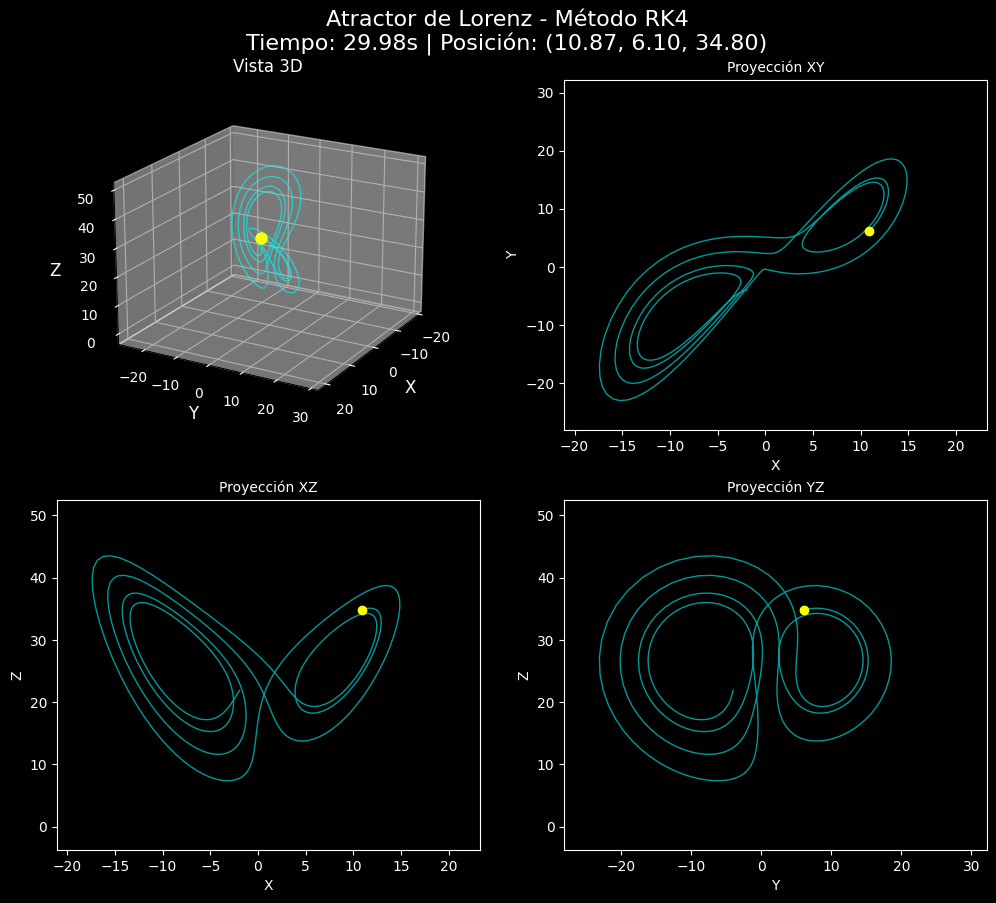

In [5]:
def generate_animation():
    animation_data = generate_animation_data()

    # PASO 1: Obtener datos
    t = animation_data['tiempo']
    x = animation_data['x_rk4']  # o x_euler
    y = animation_data['y_rk4']
    z = animation_data['z_rk4']
    
    # PASO 2: Crear el animador
    animator = LorenzAnimator(t, x, y, z, method_name="RK4")
    
    # PASO 3: Generar la animación, validando si el códec MP4 es válido o no
    if (verify_ffmpeg_liveness()):
        anim = animator.create_animation(
            filename="lorenz_rk4_animation.mp4",
            fps=30,
            duration=50,
            dpi=150
        )
    else:
        anim = animator.create_animation(
            filename="lorenz_rk4_animation.gif",
            fps=25,
            duration=30,
            dpi=100
        )

if __name__ == "__main__":
    generate_animation()